# Modelowanie układów przepływowych - Projekt pierwszy

pytanie - Jak zachowuje się fala, gdy na dnie znajduje się znaczne wgłębienie? Jaki jest przekrój wychylenia $\xi$ w projekcji na oś y po przejściu przez dołek?

In [1]:
import sys
import numpy as np
from matplotlib import pyplot
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions

In [2]:
def intro():
    pyplot.figure(figsize=(12, 2))
    pyplot.axis('off')

    arrow_kwargs = {
        'length_includes_head': True,
        'head_width': 0.009,
        'head_length': 0.12
    }

    # batymetria (dołek)
    pyplot.fill_between(x, b, np.min(b)-1, color='brown', alpha=.4, label='$z=-b$')

    # fala
    pyplot.fill_between(x, h, b, color='blue', alpha=.15, label=r'$z=\zeta$')

    # strzałki
    ix = int(nx * 0.3)
    pyplot.arrow(x[ix], b[ix], 0, -b[ix], color='brown', **arrow_kwargs)
    pyplot.arrow(x[ix], 0, 0, b[ix], color='brown', **arrow_kwargs)
    pyplot.annotate("  $b$", xy=(x[ix], b[ix]+0.2), color='brown')

    ix = int(nx * 0.52)
    pyplot.arrow(x[ix], 0, 0, h[ix], color='blue', **arrow_kwargs)
    pyplot.arrow(x[ix], h[ix], 0, -h[ix], color='blue', **arrow_kwargs)
    pyplot.annotate("  $\\zeta$", xy=(x[ix], h[ix]-0.3), color='blue')

    ix = int(nx * 0.75)
    pyplot.arrow(x[ix], 0, 0, h[ix], color='black', **arrow_kwargs)
    pyplot.arrow(x[ix], 0, 0, b[ix], color='black', **arrow_kwargs)
    pyplot.annotate("  $h$", xy=(x[ix], b[ix]+0.4), color='black')
    pyplot.plot(x, np.full_like(x, 0), linestyle='--', color='black', label='$z=0$')
    pyplot.legend(loc="upper right")
    show_plot("bathymetry")

## Opis układu: symbole i równania

Na poniższym rysunku można podglądowo zobaczyć, jak będzie wyglądał układ w projekcji na oś x. Używanymi pojęciami są:

Batymetria b(x) - kształt dna zadany w projekcie jest dany wzorem: $0.01 + A_b \cdot exp(-(\frac{(x-x_c)^2+(y-y_c)^2}{r^2}))$, gdzie $x_c$ oraz $y_c$ są współrzędnymi określającymi środek wgłębienia na dnie, natomiast r jest jego promieniem.

Wysokość fali $z = \zeta(t,x)$, dana wzorem: z(x)=$A\cdot exp(-(\frac{(x-x_0)^2}{2\sigma^2}))$ - ($\sigma=\frac{w}{2.355}$, gdzie w-szerokość fali) analogicznym jak w przypadku batymetrii, lecz w jednym wymiarze. W przekroju jest ona gaussem z tego względu, że chciałabym uniknąć bardzo gwałtownych zmian w przestrzeni w celu zachowania stabilności algorytmu.

Całkowita wysokość wody $h(t,x) = \zeta (x) + b(x)$.

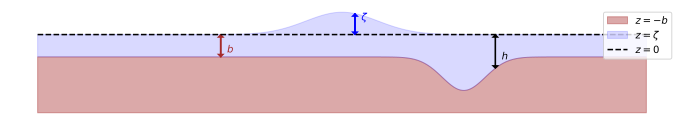

In [9]:
nx = 400
x = np.linspace(0, 1, nx)
y0 = 0.5
cx, cy = 0.7, 0.5
bump_amp = 1.5
radius_factor = 0.0025
x0 = 0.5
wave_amplitude = 1
wave_thickness = 0.007
z = wave_amplitude * np.exp(-((x - x0)**2) / wave_thickness)
b = -(1 + bump_amp * np.exp(-((x - cx)**2) / radius_factor))
h = z

intro()

$$
\begin{cases}
  \partial_t h + \nabla \cdot (\vec{u}h) =\! 0\\
  \partial_t (hu) +\nabla \cdot (\vec{u}hu)=\! - gh\partial_x\zeta \\
  \partial_t (hv) +\nabla \cdot (\vec{u}hv) =\! - gh\partial_y\zeta
\end{cases}
$$
Układ opisują równania płytkiej wody. Pierwsze równanie wyraża zasadę zachowania masy. Dwa kolejne to równania zachowania pędu, uwzględniające adwekcję oraz siły wynikające z gradientu ciśnienia - grawitacji i nachylenia powierzchni $\zeta$.

## Warunki początkowe oraz analiza

In [ ]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray, bathymetry: np.ndarray, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }

        self.bathymetry = bathymetry
        self.t=0.0

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']-self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 #srednia dwoch sasiednich komorek w v
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        if (np.amax(np.abs(courant_number)) >= 1):
            print(np.amax(np.abs(courant_number)))
        assert np.amax(np.abs(courant_number)) <= 1

    def get_velocity_fields(self, eps: float=1e-8):
        """Zwraca (u, v) pola prędkości jako macierze o wymiarach h."""
        mask = self['h'] > eps
        u = np.zeros_like(self['h'])
        v = np.zeros_like(self['h'])
        # bez dzielenia przez 0
        np.divide(self['uh'], self['h'], where=mask, out=u)
        np.divide(self['vh'], self['h'], where=mask, out=v)
        return u, v

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        output['t'] = [] # czas -> bo dla danego dt/dxy jezeli chce zmienic gestosc siatki, to dxy maleje -> musze dt zmienic aby zachowac te sama liczbe couranta co podana w argumencie - do tego na czasie latwiej mi bedzie sledzic czas do pozniejszych porownan niz w liczbie iteracji
        nx, ny = self['h'].shape
        dx = 1.0 / (nx - 1)
        dy = 1.0 / (ny - 1)
        dt = min(dt_over_dxy[0] * dx, dt_over_dxy[1] * dy)

        T_output_step = outfreq * dt #zapisuje co konkretny interwal czasowy, a nie co x iteracji
        T_output_next = 0.0

        for it in range(nt + 1):
            if self.t >= T_output_next:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
                output['t'].append(self.t)
                T_output_next += T_output_step
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis]) #operators splitting
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
            self.t += dt
        return output

In [ ]:
def make_bathymetry_and_initial(nx, ny,bump_center, bump_amp,bump_radius_m,wave_amplitude,wave_position_factor):

    X, Y = np.meshgrid(
        np.linspace(0, 1, nx),
        np.linspace(0, 1, ny),
        indexing='ij'
    )
    r2 = bump_radius_m**2
    bathymetry = 0.01 + bump_amp * np.exp(-((X - bump_center[0])**2 + (Y - bump_center[1])**2) / r2)

    h_initial = bathymetry.copy()
    wave_width_m = 0.1
    sigma = wave_width_m / 2.355
    x0 = wave_position_factor * 1.0
    x = np.linspace(0, 1, nx)
    gauss = wave_amplitude * np.exp(-((x - x0)**2) / (2 * sigma**2))
    h_initial += gauss[:, None]

    return h_initial, bathymetry

def run_sim(grid=(160,160),dt_over_dxy=(0.4, 0.4),nt=500,res_factor=1,dt_factor=1,lens_center=(0.7,0.5),lens_depth=0.03):
    nx0, ny0 = grid
    nx = nx0 * res_factor
    ny = ny0 * res_factor

    dt_over_dxy_space = (dt_over_dxy[0] * res_factor, dt_over_dxy[1] * res_factor)
    dt_over_dxy_final = (dt_over_dxy_space[0] / dt_factor, dt_over_dxy_space[1] / dt_factor)

    nt_final = nt * dt_factor #potrzeba wiecej krokow jesli krok jest mniejszy, aby dojsc do tego samego momentu czasowego np 2s.

    h0, bath = make_bathymetry_and_initial(nx=nx,ny=ny,bump_center=lens_center,bump_amp=lens_depth,bump_radius_m=0.08, wave_amplitude=0.001,wave_position_factor=0.5)
    out = ShallowWaterEquationsIntegrator(h_initial=h0,bathymetry=bath)(nt=nt_final,g=9.81,dt_over_dxy=dt_over_dxy_final,outfreq=3*dt_factor)

    return out, bath


Batymetria jest dana wzorem: $0.01 \text{ m} + 0.03\text{ m} \cdot \exp(-(\frac{(x-0.7\text{ m})^2+(y-0.5\text{ m})^2}{0.08^2\text{ m}}))$

natomiast fala początkowa: $\zeta (t=0,x)=0.001 \text{ m}\cdot \exp(-(\frac{(x-0.5\text{ m})^2}{2\cdot (0.01/2.355)^2 \text{ m}}))$

Symulacje przeprowadzono dla parametrów N (160, 160) oraz (320, 320) na siatce o rozmiarze 1 x 1 metra oraz dt/dx (0.4, 0.4), (0.2, 0.2), (0.1, 0.1). W ten sposób zbadano wpływ zagęszczenia siatki oraz zmniejszenia kroku czasowego dwa razy na wyniki symulacji.

In [ ]:
out1, bath1 = run_sim(res_factor=1, dt_factor=1)

In [ ]:
out2, bath2 = run_sim(res_factor=2, dt_factor=1)

In [ ]:
out3, bath3 = run_sim(res_factor=1, dt_factor=2)

In [ ]:
out4, bath4 = run_sim(res_factor=2, dt_factor=2)

In [ ]:
def plot_velocity_frames(out, frames, step=3): #step równy 3 zeby rysowalo co 3 strzalke - ianczej pdf mi sie ladowal 15 minut
    fig, axes = pyplot.subplots(1, 2, figsize=(8, 2.6))
    axes = axes.flatten()
    for idx, frame in enumerate(frames):
        ax = axes[idx]
        h  = out["h"][frame]
        uh = out["uh"][frame]
        vh = out["vh"][frame]
        t_sec = out['t'][frame]
        u = uh / h
        v = vh / h
        nx, ny = u.shape
        X, Y = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')

        ax.quiver(X[::step, ::step],Y[::step, ::step],u[::step, ::step],v[::step, ::step],angles='xy', scale_units='xy')
        ax.set_aspect('equal')
        ax.set_title(f"Pole prędkości     t = {t_sec:.3f} s", fontsize=10)
        ax.set_xlabel(r'x/$\Delta$x')
        ax.set_ylabel(r'y/$\Delta$y')
        ax.grid(alpha=0.25)
    fig.text(0.5, -0.03, "Rys. 2 Pola prędkości dla wybranych klatek czasowych", ha="center", fontsize=10)
    pyplot.tight_layout()
    fig.subplots_adjust(wspace=0.05, hspace=0.25)
    show_plot("velocity_frames_grid")


In [ ]:
def plot_height_frames(out, bath, frames):
    fig, axes = pyplot.subplots(1, 2, figsize=(6, 3))
    axes = axes.flatten()

    for idx, frame in enumerate(frames):
        ax = axes[idx]
        h = out["h"][frame]
        t_sec = out['t'][frame]
        zeta = (h - bath) * 100  # cm

        im = ax.imshow(zeta, origin='lower', cmap='viridis')
        ax.set_aspect("equal")
        ax.set_title(f"wysokość ζ    t = {t_sec:.3f} s", fontsize=9)
        ax.set_ylabel(r'x/$\Delta$x')
        ax.set_xlabel(r'y/$\Delta$y')

        cbar = fig.colorbar(im, ax=ax, shrink=0.85)
        cbar.set_label("ζ [cm]")

    fig.text(0.5, -0.03, "Rys. 1 Wysokość ζ = h − bath dla wybranych klatek czasowych", ha="center", fontsize=9)

    pyplot.tight_layout()
    show_plot("height_frames_grid_individual_cbars")

In [ ]:
def plot_cross_section_frames(out_list, bath_list, frames, pos, axis='x', Lx=1.0, Ly=1.0):
    colors     = ["#F29BC5", "#81A684", "darkorange", "#2C1320"]
    linestyles = ["solid", "dashed", (0, (5, 5)), (0, (1, 5))]
    labels     = ["ref", "2× grid", "dt/2", "2× grid and dt/2"]

    fig, axes = pyplot.subplots(2, 2, figsize=(12, 6))
    axes_flat = axes.ravel()
    used_axes = axes_flat[:len(frames)]

    for ax, frame in zip(used_axes, frames):
        t_sec = out_list[0]['t'][frame]

        for k, out in enumerate(out_list):
            h = out['h'][frame]
            zeta = (h - bath_list[k]) * 100.0   # cm
            nx, ny = zeta.shape
            x = np.linspace(0, Lx, nx)
            y = np.linspace(0, Ly, ny)

            step_x = max(1, nx // 300)
            step_y = max(1, ny // 300)

            if axis == 'x':
                j = int((pos / Ly) * (ny - 1))
                j = np.clip(j, 0, ny - 1)
                ax.plot(x[::step_x], zeta[:, j][::step_x],
                        label=labels[k], color=colors[k],
                        linestyle=linestyles[k], lw=2.0, alpha=0.85)
                ax.set_xlabel("x [m]",fontsize=14)
            elif axis == 'y':
                i = int((pos / Lx) * (nx - 1))
                i = np.clip(i, 0, nx - 1)
                ax.plot(y[::step_y], zeta[i, :][::step_y],
                        label=labels[k], color=colors[k],
                        linestyle=linestyles[k], lw=2.0, alpha=0.85)
                ax.set_xlabel("y [m]",fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.tick_params(axis='both', which='minor', labelsize=12)
        ax.set_title(f"t = {t_sec:.3f} s",fontsize=16)
        ax.set_ylabel("ζ [cm]", fontsize=14)
        ax.grid(alpha=0.3)

    for ax in axes_flat[len(frames):]:
        ax.set_visible(False)

    axes_flat[0].legend()
    fig.subplots_adjust(bottom=0.15)

    if axis == 'x':
        rys_num = 2
    else:
        rys_num = 3
    title_text = f"Przekrój ζ({axis}) w przekroju={pos:.2f} m"
    pyplot.tight_layout()
    fig.text(0.5, 0.42, f"Rys. {rys_num}: {title_text}", ha="center", fontsize=16)

    pyplot.tight_layout()
    show_plot(f"cross_section_multi_axis={axis}")

In [ ]:
def show_simulation(out_list, bath_list, frames, plot, x_section_pos=0.5, y_section_pos=0.9):
    if plot == 'velocity':
        plot_velocity_frames(out_list[0], frames)
    if plot == 'height':
        plot_height_frames(out_list[0],bath_list[0], frames)
    if plot == 'cross-section':
        plot_cross_section_frames(out_list, bath_list, frames,pos=x_section_pos, axis='x')
        plot_cross_section_frames(out_list, bath_list, frames, pos=y_section_pos, axis='y')

In [ ]:
frames=[30,105]
out_list=[out1, out2,out3, out4]
bath_list=[bath1, bath2,bath3, bath4]
show_simulation(out_list=out_list,bath_list=bath_list,frames=frames,plot='height',x_section_pos=0.5,y_section_pos=0.9)

Powyżej przedstawiono, jak wygląda mapa $\zeta$ w funkcji położenia w osi x oraz y dla rozmiaru siatki 160x160 oraz kroku dt/dx = 0.2. Można zaobserwować zwiększenie się prędkości fali przechodzącej nad dołkiem - widać to jako przesunięcie się czoła fali na przód. Wynika to z zależności $c=\sqrt{gh}$, gdzie c jest prędkością fali, h - wysokością słupa wody, a g - przyśpieszeniem grawitacyjnym.

In [ ]:
show_simulation(out_list=out_list,bath_list=bath_list, frames=frames,plot='velocity',x_section_pos=0.5,y_section_pos=0.9)

Powyżej przedstawiono pole wektorowe prędkości rozchodzących się fal dla rozmiaru siatki 160x160 oraz kroku dt/dx = 0.2.

In [ ]:
frames=[100,155]
show_simulation(out_list=out_list,bath_list=bath_list,frames=frames, plot='cross-section',x_section_pos=0.5,y_section_pos=0.9)

Przedstawiono profile $\zeta$ dla przekrojów $y=0.5$ m i $x=0.9$ m, porównując wpływ parametrów siatki. Fala pokonująca dołek ma mniejszą amplitudę i ulega rozmyciu. Wynika to z przyspieszenia nad głębszym dnem ($c=\sqrt{hg}$). Zmiana siatki i kroku czasowego nie wpłynęła na wynik jakościowo - małe różnice wynikają z lepszego odwzorowania batymetrii dla gęstszej siatki. Dodatkowo w przekroju $y=0.5$ m widoczne jest częściowe odbicie fali od gwałtownego spadku. Dla przekroju $x=0.9$ m pojawia się czoło fali o amplitudzie ok. 0.006 cm. Obserwowane później maksima (dla $y=0.3$ i $0.7$ m na drugim rysunku) wynikają z rozpraszania fali na dołku w osi y i jej interferencji z falą nierozproszoną.

## Odpowiedź na pytanie:

Przechodząc nad dołkiem fala przyspiesza, ponieważ w głębszej wodzie porusza się szybciej. Przez to, że jej środkowa część wyprzedza resztę, czoło fali przyjmuje łukowaty kształt. Dodatkowo ta przyspieszona część fali zaczyna nakładać się na tę, która nie oddziaływała z dołkiem, co powoduje lokalne wypiętrzenie. Jakościowo symulacje są takie same niezależnie od parametrów siatki i kroku czasowego. Różnice liczbowe między siatką normalną oraz 2x gęstszą wynikają z tego, że batymetria jest lepiej odwzorowana na gęstej siatce – dołek jest mały powierzchniowo, ale głęboki, co wpływa na trudność w uchwyceniu jego rozdzielczości.